Este notebook faz parte de uma avaliação do curso do SCTEC - Machine Learning e Visão Computacional 

Utilizei o dataset público Casting Product Image Data for Quality Inspection (https://drive.google.com/file/d/1K5gNxQ7RXA-nb4boNzPYQTJlRvJyYBD1/view?usp=sharing), que contém imagens reais de peças de fundição com e sem defeitos. 

Trata-se de um desafio técnico para desenvolver um pipeline (script) em Python utilizando a biblioteca OpenCV para realizar o pré-processamento de um lote de imagens de peças metálicas.
Ele prepara as imagens para que, a equipe de Machine Learning possa treinar um modelo preditivo. Aplico uma sequência lógica de filtros e transformações (como conversão para escala de cinza, suavização, limiarização, operações morfológicas e detecção de bordas) que evidenciem as ranhuras e defeitos estruturais das peças, salvando o resultado final de forma padronizada.

A Sprint 1 foi concluída, pois correspondeu à etapa de setup inicial do projeto.


Sprint 2
Uma estrutura de pastas (/raw_images e /processed_images) foi criada. Em /raw_images, estão armazenadas as imagens baixadas do dataset.

Inicio esta segunda parte da Sprint 2 para desenvolver a lógica para ler múltiplas imagens do diretório de entrada em lote (batch).

In [2]:
# Importa as bibliotecas
import cv2
from pathlib import Path


In [3]:
# Processamento em lote
# 
input_dir = Path("raw_images")
def read_images_batch(input_dir):
    """
    Lê todas as imagens da pasta e subpastas de entrada.
    Retorna uma lista com as imagens carregadas na memória.
    """
    
    image_extensions = {".jpg", ".jpeg", ".png"}
   
    try:
        # Busca somente arquivos de imagem
        image_files = [
            file for file in input_dir.rglob("*")
            if file.is_file() and file.suffix.lower() in image_extensions
        ]

        # Verifica se existem imagens
        if not image_files:
            raise FileNotFoundError(
                "Nenhuma imagem foi encontrada no diretório de entrada."
            )

        # Lê as imagens
        images = []

        for file in image_files:
            image = cv2.imread(str(file))

            if image is not None:
                images.append(image)

        # Mostra os resultados da leitura
        print(f"Arquivos de imagem encontrados: {len(image_files)}")
        print(f"Imagens carregadas na memória: {len(images)}")
        if len(image_files) == len(images):
            print("Leitura das imagens realizada com sucesso.")
        else:
            print("Atenção: nem todas as imagens foram carregadas.")
        return images

    # Caso não encontre imagens, trata o erro:
    except FileNotFoundError as error:
        print(f"Erro: {error}")
        return []

    except Exception as error:
        print(f"Ocorreu um erro durante a leitura das imagens: {error}")
        return []


In [4]:
images = read_images_batch(input_dir)

Arquivos de imagem encontrados: 1300
Imagens carregadas na memória: 1300
Leitura das imagens realizada com sucesso.


Sprint 3:
 Pipeline de Pré-processamento Base: Implementar conversão para escala de cinza (Grayscale) e 
 aplicação de filtro para redução de ruído (ex: Gaussian Blur ou Median Blur).

In [5]:
def preprocess_images(images):
    """
    Converte as imagens para escala de cinza
    e aplica Gaussian Blur para redução de ruído.
    """

    gray_images = []
    blur_images = []

    for image in images:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        gray_images.append(gray)

        blur = cv2.GaussianBlur(gray, (5, 5), 0)
        blur_images.append(blur)

    print(f"Pré-processamento concluído: {len(images)} imagens processadas.")
    return gray_images, blur_images

Sprint 4:
Segmentação e Destaque de Características: 
Aplicar técnicas de limiarização (Thresholding, como o método de Otsu) e detecção de bordas (ex: Canny ou Sobel) para destacar os contornos da peça e possíveis falhas

In [6]:
sample_images = images[:5]

print(f"Amostra selecionada: {len(sample_images)} imagens")

Amostra selecionada: 5 imagens


In [7]:
gray_sample, blur_sample = preprocess_images(sample_images)

Pré-processamento concluído: 5 imagens processadas.


In [8]:
def process_sprint4(blur_images):
    """
    Aplica thresholding de Otsu e detecção de bordas Canny
    às imagens suavizadas.
    """
    threshold_images = []
    otsu_thresholds = []
    canny_images = []

    for blur in blur_images:
        # Thresholding com Otsu
        otsu_threshold, binary = cv2.threshold(
            blur,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        threshold_images.append(binary)
        otsu_thresholds.append(otsu_threshold)

        # Detecção de bordas com Canny
        edges = cv2.Canny(blur, 50, 150)
        canny_images.append(edges)

    print(f"Sprint 4 concluído: {len(blur_images)} imagens processadas.")

    return threshold_images, otsu_thresholds, canny_images

In [9]:
threshold_sample, otsu_thresholds, canny_sample = process_sprint4(blur_sample)

Sprint 4 concluído: 5 imagens processadas.


Sprint 5:
Refinamento Morfológico e Padronização: Utilizar operações morfológicas (Erosão/Dilatação) para remover ruídos da segmentação e redimensionar (Resize) todas as imagens para um tamanho padrão (ex: 256x256 pixels).

In [27]:
def process_sprint5(canny_images, size=(256, 256)):
    """
    Aplica redimensionamento e fechamento morfológico
    nas imagens resultantes da detecção de bordas Canny.
    """
    processed_images = []

    # Elemento estruturante 3x3
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (3, 3)
    )

    for canny in canny_images:

        # Redimensionamento
        resized = cv2.resize(
            canny,
            size,
            interpolation=cv2.INTER_AREA
        )

        # Fechamento morfológico
        closing = cv2.morphologyEx(
            resized,
            cv2.MORPH_CLOSE,
            kernel
        )

        processed_images.append(closing)

    print(f"Sprint 5 concluído: {len(canny_images)} imagens processadas.")

    return processed_images

In [28]:
sprint5_sample = process_sprint5(canny_sample)

Sprint 5 concluído: 5 imagens processadas.


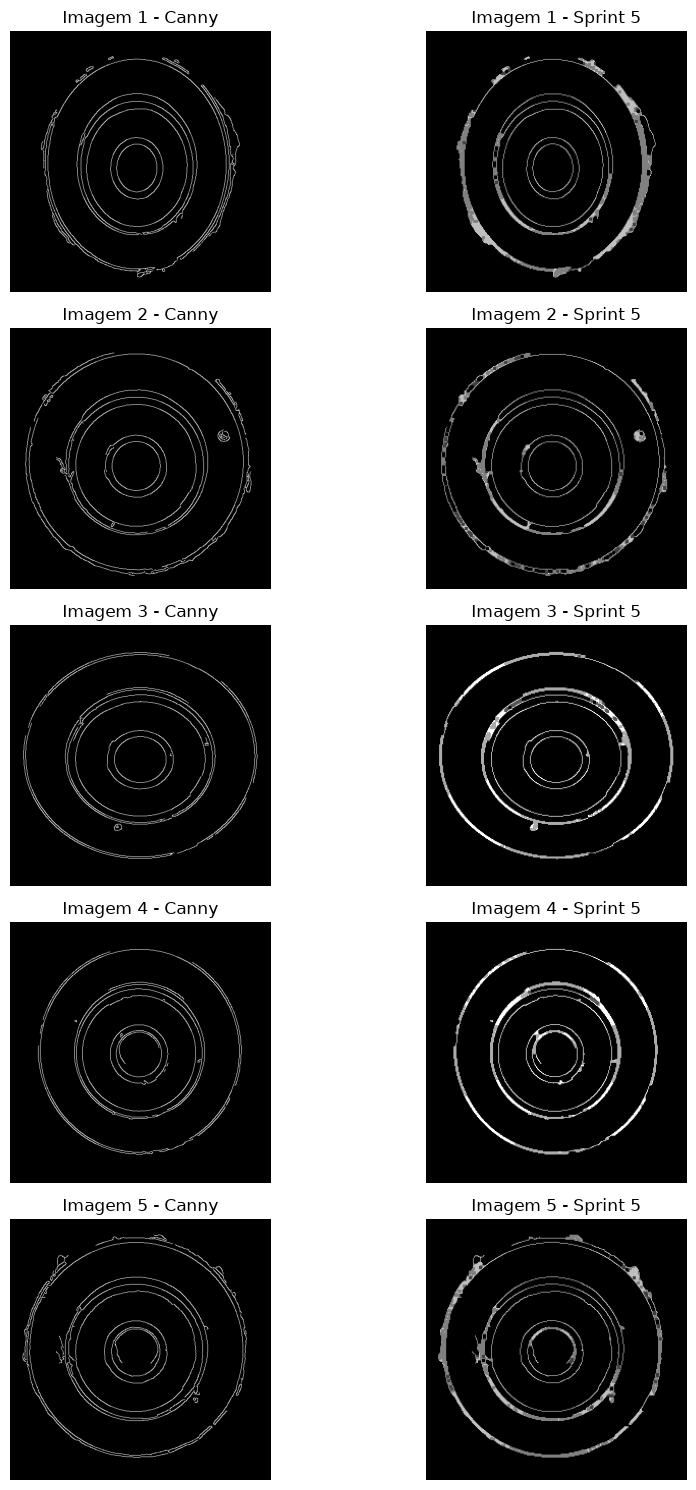

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(sprint5_sample), 2, figsize=(10, 15))

for i in range(len(sprint5_sample)):
    axes[i, 0].imshow(canny_sample[i], cmap="gray")
    axes[i, 0].set_title(f"Imagem {i+1} - Canny")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sprint5_sample[i], cmap="gray")
    axes[i, 1].set_title(f"Imagem {i+1} - Sprint 5")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

### Resultado do Sprint 5

As imagens resultantes da detecção de bordas Canny foram redimensionadas para 256x256 pixels e submetidas ao fechamento morfológico (Closing) com kernel 3x3.

O fechamento morfológico foi escolhido por apresentar melhor preservação e conexão das bordas da peça. A operação de abertura (Opening) foi testada, mas removeu partes relevantes das bordas finas nas imagens analisadas.

Pipeline definido no Sprint 5: Canny → Resize 256x256 → Closing 3x3
O resultado foi validado visualmente nas cinco imagens da amostra.